In [97]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Set project root directory
ROOT = Path.cwd()

# If the notebook is running from the notebooks folder, go back to project root
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

processed_dir = ROOT / "data" / "processed"
figures_dir = ROOT / "figures"

figures_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Processed data folder:", processed_dir)

Project root: c:\Time series
Processed data folder: c:\Time series\data\processed


In [98]:
final_df = pd.read_csv(
    processed_dir / "weekly_pjme_consumption_processed.csv",
    parse_dates=["Datetime"],
    index_col="Datetime"
)

# Make sure index is sorted
final_df = final_df.sort_index()

# Define target variable
y = final_df["Weekly_Electricity_Consumption_MWh"]

print(final_df.info())
display(final_df.head())
display(final_df.tail())

print("Start date:", y.index.min())
print("End date:", y.index.max())
print("Number of observations:", len(y))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 864 entries, 2002-01-13 to 2018-07-29
Data columns (total 1 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Weekly_Electricity_Consumption_MWh  864 non-null    float64
dtypes: float64(1)
memory usage: 13.5 KB
None


,Weekly_Electricity_Consumption_MWh
Datetime,
2002-01-13,5289881.0
2002-01-20,5284084.0
2002-01-27,5063777.0
2002-02-03,4905010.0
2002-02-10,5233287.0


,Weekly_Electricity_Consumption_MWh
Datetime,
2018-07-01,6033189.0
2018-07-08,6461277.0
2018-07-15,6118566.0
2018-07-22,5982832.0
2018-07-29,6145746.0


Start date: 2002-01-13 00:00:00
End date: 2018-07-29 00:00:00
Number of observations: 864


In [99]:
train = pd.read_csv(
    processed_dir / "train_weekly_pjme.csv",
    parse_dates=["Datetime"],
    index_col="Datetime"
)["Weekly_Electricity_Consumption_MWh"]

val = pd.read_csv(
    processed_dir / "validation_weekly_pjme.csv",
    parse_dates=["Datetime"],
    index_col="Datetime"
)["Weekly_Electricity_Consumption_MWh"]

test = pd.read_csv(
    processed_dir / "test_weekly_pjme.csv",
    parse_dates=["Datetime"],
    index_col="Datetime"
)["Weekly_Electricity_Consumption_MWh"]

print("Train:", train.index.min(), "to", train.index.max(), "| size:", len(train))
print("Validation:", val.index.min(), "to", val.index.max(), "| size:", len(val))
print("Test:", test.index.min(), "to", test.index.max(), "| size:", len(test))

Train: 2002-01-13 00:00:00 to 2017-04-30 00:00:00 | size: 799
Validation: 2017-05-07 00:00:00 to 2018-04-29 00:00:00 | size: 52
Test: 2018-05-06 00:00:00 to 2018-07-29 00:00:00 | size: 13


In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def evaluate_forecast(actual, forecast):
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    accuracy = 100 - mape
    
    return mae, rmse, mape, accuracy

## Baseline Model

In [101]:
# Naive baseline: forecast equals the last observed value in the training set
naive_val_forecast = pd.Series(
    train.iloc[-1],
    index=val.index,
    name="Naive_Validation_Forecast"
)

naive_val_mae, naive_val_rmse, naive_val_mape, naive_val_accuracy = evaluate_forecast(
    val,
    naive_val_forecast
)

print("Naive Baseline - Validation Evaluation")
print("MAE:", naive_val_mae)
print("RMSE:", naive_val_rmse)
print("MAPE:", naive_val_mape)
print("Forecast Accuracy:", naive_val_accuracy)

Naive Baseline - Validation Evaluation
MAE: 696455.9615384615
RMSE: 907398.4261897178
MAPE: 12.270658097277527
Forecast Accuracy: 87.72934190272247


In [102]:
def seasonal_naive_forecast(history, steps, seasonal_period=52):
    """
    Multi-step seasonal naive forecast.
    Forecast each future value using the value from seasonal_period periods before.
    This function does not use actual validation or test values during forecasting.
    """
    history = list(history)
    forecasts = []

    for i in range(steps):
        forecast = history[-seasonal_period]
        forecasts.append(forecast)
        history.append(forecast)

    return np.array(forecasts)

seasonal_naive_val_values = seasonal_naive_forecast(
    train.values,
    steps=len(val),
    seasonal_period=52
)

seasonal_naive_val_forecast = pd.Series(
    seasonal_naive_val_values,
    index=val.index,
    name="Seasonal_Naive_Validation_Forecast"
)

sn_val_mae, sn_val_rmse, sn_val_mape, sn_val_accuracy = evaluate_forecast(
    val,
    seasonal_naive_val_forecast
)

print("Seasonal Naive Baseline - Validation Evaluation")
print("MAE:", sn_val_mae)
print("RMSE:", sn_val_rmse)
print("MAPE:", sn_val_mape)
print("Forecast Accuracy:", sn_val_accuracy)

Seasonal Naive Baseline - Validation Evaluation
MAE: 432658.6923076923
RMSE: 603947.0101340957
MAPE: 8.239859788600356
Forecast Accuracy: 91.76014021139964


In [103]:
baseline_validation_results = pd.DataFrame([
    {
        "Model": "Naive Baseline",
        "Description": "Forecast equals last observed training value",
        "Validation_MAE": naive_val_mae,
        "Validation_RMSE": naive_val_rmse,
        "Validation_MAPE_%": naive_val_mape,
        "Validation_Accuracy_%": naive_val_accuracy
    },
    {
        "Model": "Seasonal Naive Baseline",
        "Description": "Forecast equals same week last year, lag 52",
        "Validation_MAE": sn_val_mae,
        "Validation_RMSE": sn_val_rmse,
        "Validation_MAPE_%": sn_val_mape,
        "Validation_Accuracy_%": sn_val_accuracy
    }
])

baseline_validation_results = baseline_validation_results.round(2)

display(baseline_validation_results.sort_values("Validation_MAPE_%"))

,Model,Description,Validation_MAE,Validation_RMSE,Validation_MAPE_%,Validation_Accuracy_%
1,Seasonal Naive Baseline,"Forecast equals same week last year, lag 52",432658.69,603947.01,8.24,91.76
0,Naive Baseline,Forecast equals last observed training value,696455.96,907398.43,12.27,87.73


### Baseline Model Results

The validation results show that the seasonal naive baseline performs better than the simple naive baseline. The seasonal naive model achieves a validation MAPE of 8.24%, while the naive baseline has a higher MAPE of 12.27%.

This suggests that weekly electricity consumption contains annual seasonal information, since using the same week from the previous year provides better forecasts than simply using the last observed value. However, these baseline models are still simple benchmark methods. The ARIMA model will be evaluated against these baselines to determine whether it can provide additional forecasting improvement.

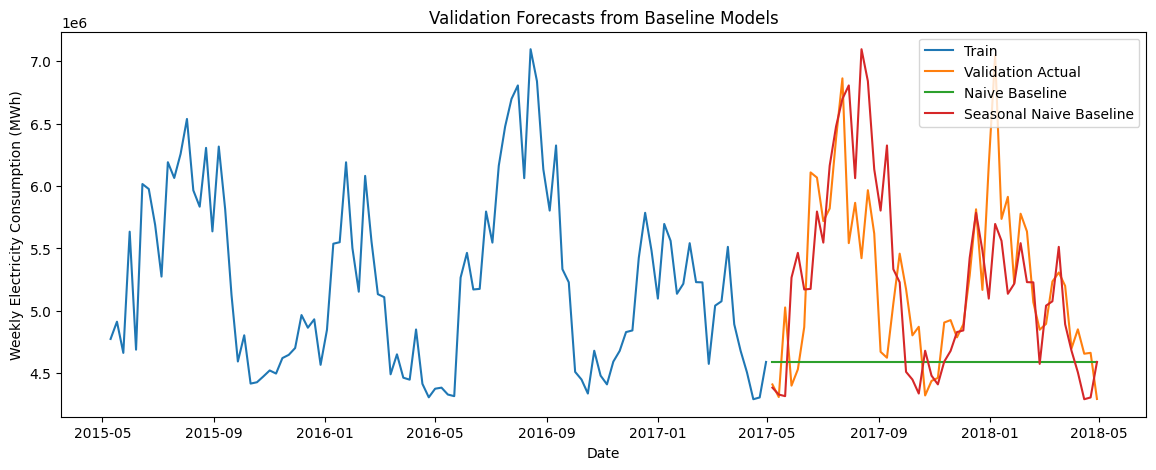

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(train.iloc[-104:], label="Train")
plt.plot(val, label="Validation Actual")
plt.plot(naive_val_forecast, label="Naive Baseline")
plt.plot(seasonal_naive_val_forecast, label="Seasonal Naive Baseline")

plt.title("Validation Forecasts from Baseline Models")
plt.xlabel("Date")
plt.ylabel("Weekly Electricity Consumption (MWh)")
plt.legend()
plt.show()

### Baseline Forecasts on the Validation Set

The figure compares the validation actual values with two baseline forecasting methods. The naive baseline produces a flat forecast because it uses the last observed value from the training set for all future validation periods. As a result, it cannot capture the fluctuations in weekly electricity consumption.

The seasonal naive baseline performs better because it uses the value from the same week in the previous year. Since the data are weekly, a seasonal lag of 52 represents annual seasonality. The seasonal naive forecast follows the validation series more closely than the simple naive forecast, suggesting that weekly electricity consumption contains annual seasonal patterns.

However, the seasonal naive model is still a simple benchmark. The ARIMA model will be evaluated against these baselines to determine whether it can provide additional forecasting improvement.

In [105]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=""):
    result = adfuller(series.dropna())

    print(f"ADF Test: {title}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")

    if result[1] < 0.05:
        print("Conclusion: Reject H0. The series is likely stationary.")
    else:
        print("Conclusion: Fail to reject H0. The series is likely non-stationary.")

adf_test(train, "Weekly Training Set")

ADF Test: Weekly Training Set
ADF Statistic: -12.370420879973064
p-value: 5.296755984935982e-23
Critical Values:
   1%: -3.438686413400388
   5%: -2.8652194721349424
   10%: -2.5687293001910008
Conclusion: Reject H0. The series is likely stationary.


### Augmented Dickey-Fuller Test

The Augmented Dickey-Fuller test is applied to the weekly training series to examine whether the series is stationary. The null hypothesis of the ADF test states that the series has a unit root, meaning that it is non-stationary.

The ADF statistic is -12.3704 and the p-value is approximately 0.0000, which is lower than the 5% significance level. Therefore, the null hypothesis is rejected. This indicates that the weekly electricity consumption series is stationary.

Since the training series is stationary, first differencing is not required. Therefore, the integration order is set to d = 0 in the ARIMA model. The validation and test sets are not used in this stationarity test to avoid data leakage.

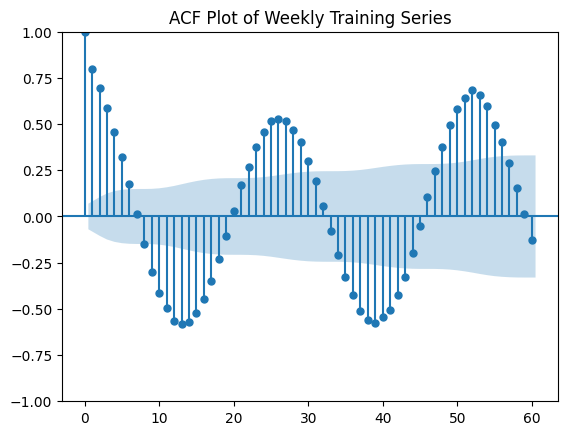

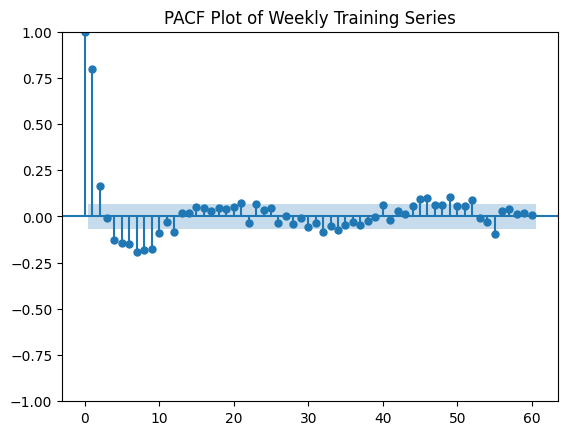

In [106]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Since ADF test suggests stationarity, use the original weekly training series
series_for_acf = train

plot_acf(series_for_acf, lags=60)
plt.title("ACF Plot of Weekly Training Series")
plt.show()

plot_pacf(series_for_acf, lags=60, method="ywm")
plt.title("PACF Plot of Weekly Training Series")
plt.show()

### ACF and PACF Analysis for Weekly Series

The ACF and PACF plots are created using only the weekly training set to avoid data leakage. Since the ADF test indicates that the weekly training series is stationary, the plots are constructed on the original training series without differencing.

The ACF plot shows a cyclical pattern, with positive autocorrelation at short lags, negative autocorrelation around intermediate lags, and strong positive autocorrelation again around lag 52. Since the data are weekly, lag 52 corresponds approximately to the same week in the previous year. This suggests the presence of annual seasonality in weekly electricity consumption.

The PACF plot shows a strong spike at lag 1 and some significant spikes at early lags, indicating that autoregressive terms are likely important. Therefore, several ARIMA(p,0,q) models with small AR and MA orders will be estimated and compared using the validation set.

The validation set and test set are not used in this model identification step.

In [107]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# ADF test suggests stationarity
d = 0

p_values = [0, 1, 2, 3, 4]
q_values = [0, 1, 2, 3, 4]

results = []

for p in p_values:
    for q in q_values:
        order = (p, d, q)

        # Skip pure mean model
        if order == (0, 0, 0):
            continue

        try:
            model = ARIMA(
                train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted_model = model.fit()

            # Forecast validation period
            forecast_result = fitted_model.get_forecast(steps=len(val))
            val_forecast = forecast_result.predicted_mean
            val_forecast.index = val.index

            # Evaluation metrics
            mae = mean_absolute_error(val, val_forecast)
            rmse = np.sqrt(mean_squared_error(val, val_forecast))
            mape = np.mean(np.abs((val - val_forecast) / val)) * 100

            results.append({
                "order": order,
                "AIC": fitted_model.aic,
                "BIC": fitted_model.bic,
                "Validation_MAE": mae,
                "Validation_RMSE": rmse,
                "Validation_MAPE": mape
            })

        except Exception as e:
            print(f"ARIMA{order} failed: {e}")

model_results = pd.DataFrame(results).sort_values("Validation_RMSE")

display(model_results)

,order,AIC,BIC,Validation_MAE,Validation_RMSE,Validation_MAPE
22,"(4, 0, 3)",22629.428338,22671.533417,356944.067801,439977.440034,6.933664
16,"(3, 0, 2)",22669.647816,22702.405011,367409.680692,455106.568700,7.231523
11,"(2, 0, 2)",22688.368820,22716.446415,389314.567015,478645.089263,7.672747
20,"(4, 0, 1)",22686.906497,22719.654892,444846.951998,541492.839982,8.810695
19,"(4, 0, 0)",22764.965451,22793.035504,535452.569127,635705.193800,10.337134
8,"(1, 0, 4)",22733.192168,22765.931752,537116.777324,638606.331726,10.328173
4,"(1, 0, 0)",22877.876256,22891.922582,539194.152849,638914.913506,10.420432
7,"(1, 0, 3)",22763.933998,22792.004050,539058.762100,640366.224578,10.369946
6,"(1, 0, 2)",22800.501589,22823.899585,542253.344906,644098.962509,10.414714
14,"(3, 0, 0)",22803.612586,22827.010582,543729.147780,646212.261980,10.429132


### Weekly ARIMA Model Selection

Several ARIMA(p,0,q) models are estimated using the weekly training set and evaluated on the validation set. Since the ADF test indicates that the weekly training series is stationary, the differencing order is set to d = 0.

The validation results show that ARIMA(4,0,3) achieves the lowest validation RMSE and MAPE among the candidate models. Therefore, ARIMA(4,0,3) is selected as the preferred weekly ARIMA model for further diagnostic checking.

The test set is not used during model selection and remains reserved for final out-of-sample evaluation.

In [108]:
best_order = (4, 0, 3)

best_model = ARIMA(
    train,
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_model_fit = best_model.fit()

print(best_model_fit.summary())

                                       SARIMAX Results                                        
Dep. Variable:     Weekly_Electricity_Consumption_MWh   No. Observations:                  799
Model:                                 ARIMA(4, 0, 3)   Log Likelihood              -11305.714
Date:                                Sat, 30 May 2026   AIC                          22629.428
Time:                                        23:12:49   BIC                          22671.533
Sample:                                    01-13-2002   HQIC                         22645.608
                                         - 04-30-2017                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.398e+06   1.14e-05   4.74e+11      0.000     5.4e+06     5.4e+06
ar.

In [109]:
alternative_order = (3, 0, 2)

alternative_model = ARIMA(
    train,
    order=alternative_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

alternative_fit = alternative_model.fit()

print(alternative_fit.summary())

                                       SARIMAX Results                                        
Dep. Variable:     Weekly_Electricity_Consumption_MWh   No. Observations:                  799
Model:                                 ARIMA(3, 0, 2)   Log Likelihood              -11327.824
Date:                                Sat, 30 May 2026   AIC                          22669.648
Time:                                        23:12:49   BIC                          22702.405
Sample:                                    01-13-2002   HQIC                         22682.235
                                         - 04-30-2017                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.398e+06   5.61e-08   9.62e+13      0.000     5.4e+06     5.4e+06
ar.

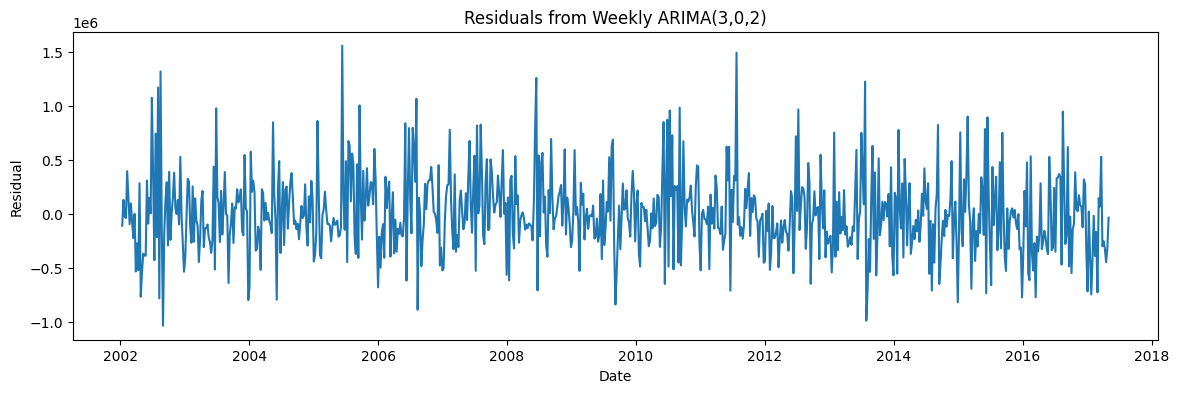

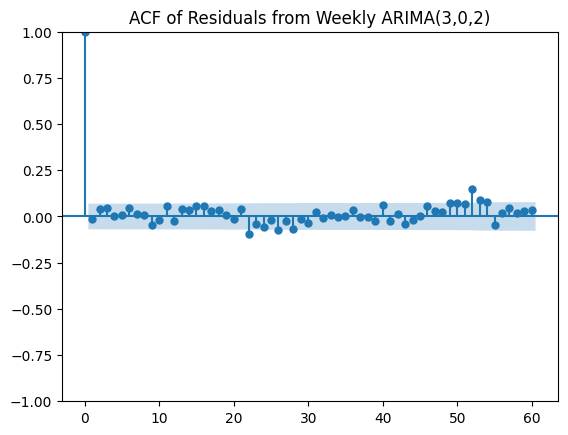

,lb_stat,lb_pvalue
4,2.991114,0.559314
13,11.188827,0.595002
26,36.596305,0.081235
52,85.702678,0.002247


In [110]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

alternative_residuals = alternative_fit.resid.dropna()

plt.figure(figsize=(14, 4))
plt.plot(alternative_residuals)
plt.title("Residuals from Weekly ARIMA(3,0,2)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

plot_acf(alternative_residuals, lags=60)
plt.title("ACF of Residuals from Weekly ARIMA(3,0,2)")
plt.show()

alternative_ljung_box = acorr_ljungbox(
    alternative_residuals,
    lags=[4, 13, 26, 52],
    return_df=True
)

display(alternative_ljung_box)

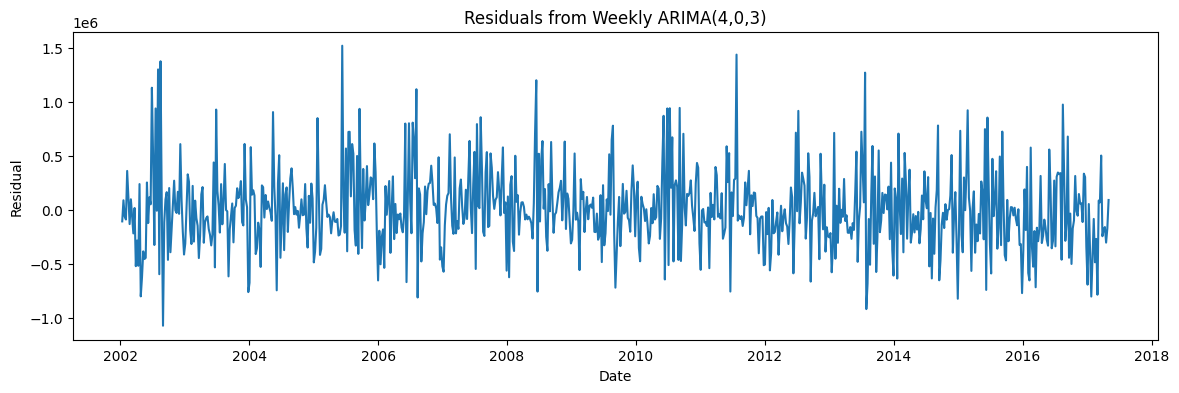

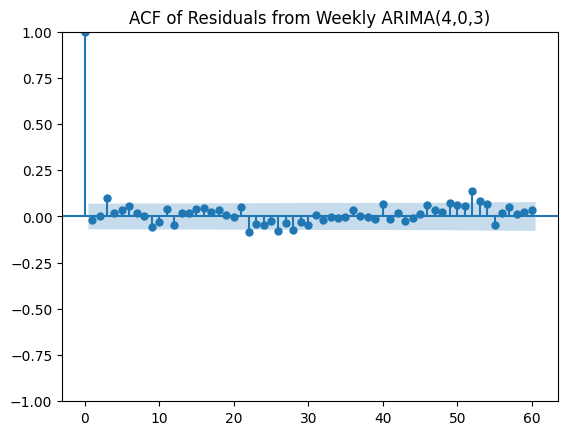

,lb_stat,lb_pvalue
4,8.471637,0.075752
13,19.115060,0.119579
26,40.077699,0.038333
52,86.658499,0.001816


In [111]:
residuals_403 = best_model_fit.resid.dropna()

plt.figure(figsize=(14, 4))
plt.plot(residuals_403)
plt.title("Residuals from Weekly ARIMA(4,0,3)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

plot_acf(residuals_403, lags=60)
plt.title("ACF of Residuals from Weekly ARIMA(4,0,3)")
plt.show()

ljung_box_403 = acorr_ljungbox(
    residuals_403,
    lags=[4, 13, 26, 52],
    return_df=True
)

display(ljung_box_403)

### Comparison between Weekly ARIMA(4,0,3) and ARIMA(3,0,2)

Although ARIMA(4,0,3) achieves the lowest validation RMSE and MAPE, its residual diagnostics indicate remaining autocorrelation at lag 26 and lag 52. Since the data are weekly, lag 52 approximately represents annual seasonality.

ARIMA(3,0,2), while having slightly higher validation errors, provides better residual diagnostic results. The Ljung-Box p-values for ARIMA(3,0,2) are insignificant at lags 4, 13, and 26, suggesting that the model captures most short- and medium-term autocorrelation. Both models still show significant autocorrelation at lag 52, indicating that annual seasonality is not fully captured by a non-seasonal ARIMA model.

Therefore, ARIMA(3,0,2) is selected as the preferred weekly ARIMA model because it provides a better balance between forecasting accuracy, residual diagnostics, and model simplicity. The remaining autocorrelation at lag 52 is treated as a limitation of the standard ARIMA model.

In [112]:
# Compare the best validation model with the selected final model
model_comparison = model_results[
    model_results["order"].isin([(4, 0, 3), (3, 0, 2)])
].copy()

# Add number of ARMA parameters for parsimony comparison
model_comparison["AR_terms"] = model_comparison["order"].apply(lambda x: x[0])
model_comparison["MA_terms"] = model_comparison["order"].apply(lambda x: x[2])
model_comparison["ARMA_terms"] = model_comparison["AR_terms"] + model_comparison["MA_terms"]

# Add selection note
model_comparison["Selection_Note"] = model_comparison["order"].apply(
    lambda x: "Lowest validation error" if x == (4, 0, 3)
    else "Selected final model: simpler with close validation performance"
)

model_comparison = model_comparison[
    [
        "order",
        "ARMA_terms",
        "Validation_MAE",
        "Validation_RMSE",
        "Validation_MAPE",
        "Selection_Note"
    ]
].sort_values("Validation_RMSE")

display(model_comparison)

,order,ARMA_terms,Validation_MAE,Validation_RMSE,Validation_MAPE,Selection_Note
22,"(4, 0, 3)",7,356944.067801,439977.440034,6.933664,Lowest validation error
16,"(3, 0, 2)",5,367409.680692,455106.568700,7.231523,Selected final model: simpler with close valid...


In [113]:
mape_403 = model_comparison.loc[
    model_comparison["order"] == (4, 0, 3),
    "Validation_MAPE"
].iloc[0]

mape_302 = model_comparison.loc[
    model_comparison["order"] == (3, 0, 2),
    "Validation_MAPE"
].iloc[0]

mape_diff = mape_302 - mape_403

print("Validation MAPE difference between ARIMA(3,0,2) and ARIMA(4,0,3):")
print(f"{mape_diff:.2f} percentage points")

Validation MAPE difference between ARIMA(3,0,2) and ARIMA(4,0,3):
0.30 percentage points


### Final Model Selection

Although ARIMA(4,0,3) achieves the lowest validation RMSE and MAPE, its residual diagnostics show remaining autocorrelation at lag 26 and lag 52. In contrast, ARIMA(3,0,2) has slightly higher validation errors but provides better residual diagnostic results at lags 4, 13, and 26.

Since ARIMA(3,0,2) offers a better balance between forecasting accuracy, residual behavior, and model simplicity, it is selected as the preferred weekly ARIMA model. The remaining autocorrelation at lag 52 suggests that annual seasonality is not fully captured by the standard ARIMA model. This limitation will be discussed in the final report, and SARIMA with annual seasonal period may be considered for future research.

In [114]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Final selected model
final_order = (3, 0, 2)

# Combine train and validation sets
train_val = pd.concat([train, val])

# Refit final model on train + validation
final_model = ARIMA(
    train_val,
    order=final_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit()

print(final_fit.summary())

                                       SARIMAX Results                                        
Dep. Variable:     Weekly_Electricity_Consumption_MWh   No. Observations:                  851
Model:                                 ARIMA(3, 0, 2)   Log Likelihood              -12078.534
Date:                                Sat, 30 May 2026   AIC                          24171.068
Time:                                        23:12:51   BIC                          24204.268
Sample:                                    01-13-2002   HQIC                         24183.787
                                         - 04-29-2018                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.388e+06    6.9e-08   7.81e+13      0.000    5.39e+06    5.39e+06
ar.

### Final Weekly ARIMA(3,0,2) Model Estimation

After selecting ARIMA(3,0,2) based on validation performance and residual diagnostics, the model is refitted using the combined training and validation sets. This allows the final model to use all available information before the test period while keeping the test set unseen for final evaluation.

The model summary shows that the AR and MA coefficients are statistically significant. The Ljung-Box test at lag 1 does not indicate significant residual autocorrelation, and the heteroskedasticity test does not provide strong evidence of changing variance.

However, the Jarque-Bera test suggests that the residuals are not normally distributed, which may be due to peak-demand weeks or unusual electricity consumption patterns. The model also reports a near-singular covariance matrix warning, so individual coefficient significance should be interpreted with caution. Therefore, the final model performance will be evaluated mainly using out-of-sample test forecasting accuracy.

In [115]:
# Get ARIMA(3,0,2) validation result from model_results
selected_arima_val = model_results[model_results["order"] == (3, 0, 2)].iloc[0]

arima_validation_result = pd.DataFrame([
    {
        "Model": "Weekly ARIMA(3,0,2)",
        "Description": "Selected ARIMA model",
        "Validation_MAE": selected_arima_val["Validation_MAE"],
        "Validation_RMSE": selected_arima_val["Validation_RMSE"],
        "Validation_MAPE_%": selected_arima_val["Validation_MAPE"],
        "Validation_Accuracy_%": 100 - selected_arima_val["Validation_MAPE"]
    }
])

validation_comparison = pd.concat(
    [baseline_validation_results, arima_validation_result],
    ignore_index=True
)

validation_comparison = validation_comparison.round(2)
validation_comparison = validation_comparison.sort_values("Validation_MAPE_%")

display(validation_comparison)

,Model,Description,Validation_MAE,Validation_RMSE,Validation_MAPE_%,Validation_Accuracy_%
2,"Weekly ARIMA(3,0,2)",Selected ARIMA model,367409.68,455106.57,7.23,92.77
1,Seasonal Naive Baseline,"Forecast equals same week last year, lag 52",432658.69,603947.01,8.24,91.76
0,Naive Baseline,Forecast equals last observed training value,696455.96,907398.43,12.27,87.73


### Validation Comparison with Baseline Models

The validation results show that the Seasonal Naive baseline performs better than the simple Naive baseline, suggesting that weekly electricity consumption contains annual seasonal information. However, the selected Weekly ARIMA(3,0,2) model achieves the lowest validation MAE, RMSE, and MAPE among the three models.

Compared with the Seasonal Naive baseline, ARIMA(3,0,2) reduces the validation MAPE from 8.24% to 7.23% and reduces RMSE from 603,947.01 MWh to 455,106.57 MWh. This indicates that the ARIMA model captures additional time-series dependence beyond simple annual seasonal repetition.

In [116]:
# Forecast test period
test_result = final_fit.get_forecast(steps=len(test))

test_forecast = test_result.predicted_mean
test_ci = test_result.conf_int()

# Align forecast index with test index
test_forecast.index = test.index
test_ci.index = test.index

display(test_forecast)
display(test_ci)

Datetime
2018-05-06    4.632112e+06
2018-05-13    4.848940e+06
2018-05-20    5.027962e+06
2018-05-27    5.198603e+06
2018-06-03    5.367494e+06
2018-06-10    5.531739e+06
2018-06-17    5.684744e+06
2018-06-24    5.818952e+06
2018-07-01    5.927244e+06
2018-07-08    6.003747e+06
2018-07-15    6.044336e+06
2018-07-22    6.046924e+06
2018-07-29    6.011600e+06
Name: predicted_mean, dtype: float64

,lower Weekly_Electricity_Consumption_MWh,upper Weekly_Electricity_Consumption_MWh
Datetime,,
2018-05-06,3.843609e+06,5.420616e+06
2018-05-13,3.964850e+06,5.733029e+06
2018-05-20,4.110438e+06,5.945486e+06
2018-05-27,4.262884e+06,6.134322e+06
2018-06-03,4.418935e+06,6.316054e+06
2018-06-10,4.573348e+06,6.490130e+06
2018-06-17,4.719105e+06,6.650384e+06
2018-06-24,4.848579e+06,6.789326e+06
2018-07-01,4.954399e+06,6.900088e+06


In [117]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

test_mae = mean_absolute_error(test, test_forecast)
test_rmse = np.sqrt(mean_squared_error(test, test_forecast))
test_mape = np.mean(np.abs((test - test_forecast) / test)) * 100

print("Final Test Evaluation - Weekly ARIMA(3,0,2)")
print("MAE:", test_mae)
print("RMSE:", test_rmse)
print("MAPE:", test_mape)

Final Test Evaluation - Weekly ARIMA(3,0,2)
MAE: 250006.38199581744
RMSE: 332071.7546145018
MAPE: 4.863703294266897


In [118]:
# Naive baseline for test
naive_test_forecast = pd.Series(
    train_val.iloc[-1],
    index=test.index,
    name="Naive_Test_Forecast"
)

naive_test_mae, naive_test_rmse, naive_test_mape, naive_test_accuracy = evaluate_forecast(
    test,
    naive_test_forecast
)

# Seasonal naive baseline for test
seasonal_naive_test_values = seasonal_naive_forecast(
    train_val.values,
    steps=len(test),
    seasonal_period=52
)

seasonal_naive_test_forecast = pd.Series(
    seasonal_naive_test_values,
    index=test.index,
    name="Seasonal_Naive_Test_Forecast"
)

sn_test_mae, sn_test_rmse, sn_test_mape, sn_test_accuracy = evaluate_forecast(
    test,
    seasonal_naive_test_forecast
)

# ARIMA final test result
arima_test_accuracy = 100 - test_mape

test_comparison = pd.DataFrame([
    {
        "Model": "Naive Baseline",
        "Description": "Forecast equals last observed week",
        "Test_MAE": naive_test_mae,
        "Test_RMSE": naive_test_rmse,
        "Test_MAPE_%": naive_test_mape,
        "Test_Accuracy_%": naive_test_accuracy
    },
    {
        "Model": "Seasonal Naive Baseline",
        "Description": "Forecast equals same week last year, lag 52",
        "Test_MAE": sn_test_mae,
        "Test_RMSE": sn_test_rmse,
        "Test_MAPE_%": sn_test_mape,
        "Test_Accuracy_%": sn_test_accuracy
    },
    {
        "Model": "Weekly ARIMA(3,0,2)",
        "Description": "Selected ARIMA model",
        "Test_MAE": test_mae,
        "Test_RMSE": test_rmse,
        "Test_MAPE_%": test_mape,
        "Test_Accuracy_%": arima_test_accuracy
    }
])

test_comparison = test_comparison.round(2)
test_comparison = test_comparison.sort_values("Test_MAPE_%")

display(test_comparison)

,Model,Description,Test_MAE,Test_RMSE,Test_MAPE_%,Test_Accuracy_%
2,"Weekly ARIMA(3,0,2)",Selected ARIMA model,250006.38,332071.75,4.86,95.14
1,Seasonal Naive Baseline,"Forecast equals same week last year, lag 52",478081.92,554567.40,8.74,91.26
0,Naive Baseline,Forecast equals last observed week,1141057.85,1313851.87,19.84,80.16


### Final Test Comparison with Baseline Models

The final test comparison confirms that the selected Weekly ARIMA(3,0,2) model outperforms both baseline models. The ARIMA model achieves the lowest test MAE, RMSE, and MAPE, with a test MAPE of 4.86% and an average forecast accuracy of 95.14%.

The Seasonal Naive baseline has a test MAPE of 8.74%, while the Naive baseline has a much higher MAPE of 19.84%. Therefore, the ARIMA model provides meaningful forecasting improvement over simple benchmark methods. This supports the use of ARIMA(3,0,2) as the final forecasting model for weekly electricity consumption.

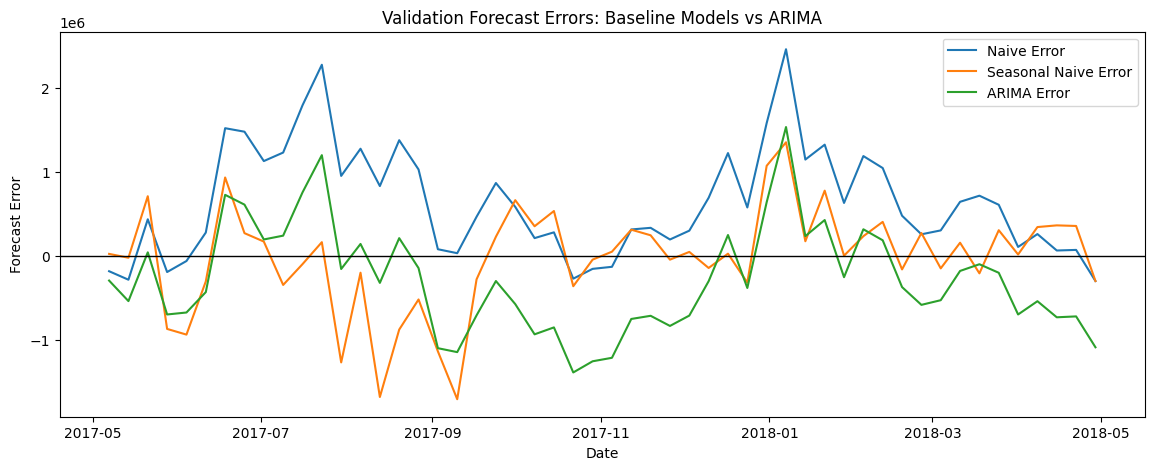

In [119]:
plt.figure(figsize=(14, 5))

plt.plot(val - naive_val_forecast, label="Naive Error")
plt.plot(val - seasonal_naive_val_forecast, label="Seasonal Naive Error")
plt.plot(val - val_forecast, label="ARIMA Error")

plt.axhline(0, color="black", linewidth=1)
plt.title("Validation Forecast Errors: Baseline Models vs ARIMA")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.show()

In [120]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Selected ARIMA order
final_order = (3, 0, 2)

# Start with train + validation data
history = train_val.copy()

rolling_forecasts = []

for i in range(len(test)):
    # Fit model on available history
    model = ARIMA(
        history,
        order=final_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    fitted = model.fit()
    
    # One-step-ahead forecast
    forecast = fitted.forecast(steps=1).iloc[0]
    rolling_forecasts.append(forecast)
    
    # After forecasting this week, add the actual observed test value to history
    history = pd.concat([history, test.iloc[[i]]])

rolling_forecast = pd.Series(
    rolling_forecasts,
    index=test.index,
    name="Rolling_ARIMA_Forecast"
)

# Evaluation
rolling_mae = mean_absolute_error(test, rolling_forecast)
rolling_rmse = np.sqrt(mean_squared_error(test, rolling_forecast))
rolling_mape = np.mean(np.abs((test - rolling_forecast) / test)) * 100
rolling_accuracy = 100 - rolling_mape

print("Rolling One-Step Test Evaluation - Weekly ARIMA(3,0,2)")
print("MAE:", rolling_mae)
print("RMSE:", rolling_rmse)
print("MAPE:", rolling_mape)
print("Forecast Accuracy:", rolling_accuracy)

Rolling One-Step Test Evaluation - Weekly ARIMA(3,0,2)
MAE: 235833.85845904166
RMSE: 287700.3917349745
MAPE: 4.446011507534642
Forecast Accuracy: 95.55398849246535


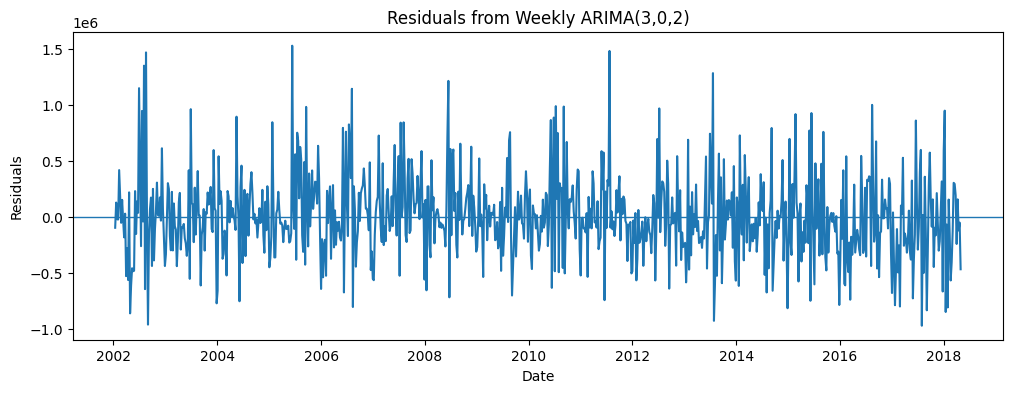

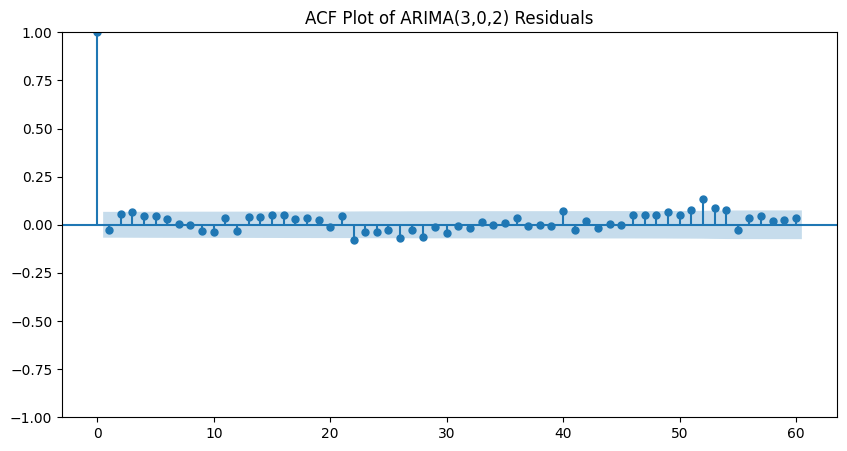

,LB_Statistic,P_Value
Lag,,
7,11.000091,0.138615
13,16.464431,0.224957
26,39.331053,0.045316
52,87.459315,0.001516


In [121]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
import pandas as pd

# ================================
# Residual diagnostics for final ARIMA model
# ================================

# Get residuals from final fitted ARIMA model
residuals = final_fit.resid.dropna()

# Plot residuals over time
plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.axhline(0, linewidth=1)
plt.title("Residuals from Weekly ARIMA(3,0,2)")
plt.xlabel("Date")
plt.ylabel("Residuals")

plt.savefig(figures_dir/"arima_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot ACF of residuals
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals, lags=60, ax=ax)
ax.set_title("ACF Plot of ARIMA(3,0,2) Residuals")

plt.savefig(figures_dir/"arima_residual_acf.png", dpi=300, bbox_inches="tight")
plt.show()

# Ljung-Box test at selected lags
# Lags are chosen to check short-term and annual autocorrelation.
lb_lags = [7, 13, 26, 52]

ljung_box_results = acorr_ljungbox(
    residuals,
    lags=lb_lags,
    return_df=True
)

ljung_box_results.index.name = "Lag"
ljung_box_results = ljung_box_results.rename(columns={
    "lb_stat": "LB_Statistic",
    "lb_pvalue": "P_Value"
})

display(ljung_box_results)

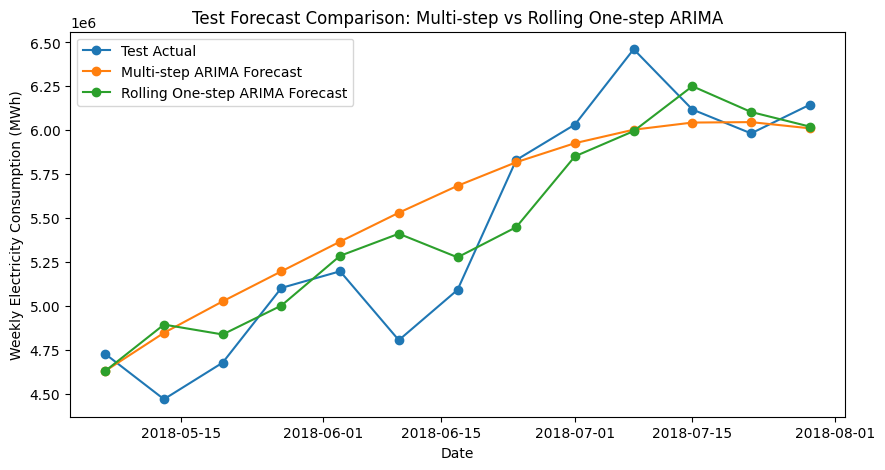

In [122]:
plt.figure(figsize=(10, 5))

plt.plot(test, marker="o", label="Test Actual")
plt.plot(test_forecast, marker="o", label="Multi-step ARIMA Forecast")
plt.plot(rolling_forecast, marker="o", label="Rolling One-step ARIMA Forecast")

plt.title("Test Forecast Comparison: Multi-step vs Rolling One-step ARIMA")
plt.xlabel("Date")
plt.ylabel("Weekly Electricity Consumption (MWh)")
plt.legend()
plt.show()

In [123]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

test_mae = mean_absolute_error(test, test_forecast)
test_rmse = np.sqrt(mean_squared_error(test, test_forecast))
test_mape = np.mean(np.abs((test - test_forecast) / test)) * 100

print("Final Test Evaluation - Weekly ARIMA(3,0,2)")
print("MAE:", test_mae)
print("RMSE:", test_rmse)
print("MAPE:", test_mape)

Final Test Evaluation - Weekly ARIMA(3,0,2)
MAE: 250006.38199581744
RMSE: 332071.7546145018
MAPE: 4.863703294266897


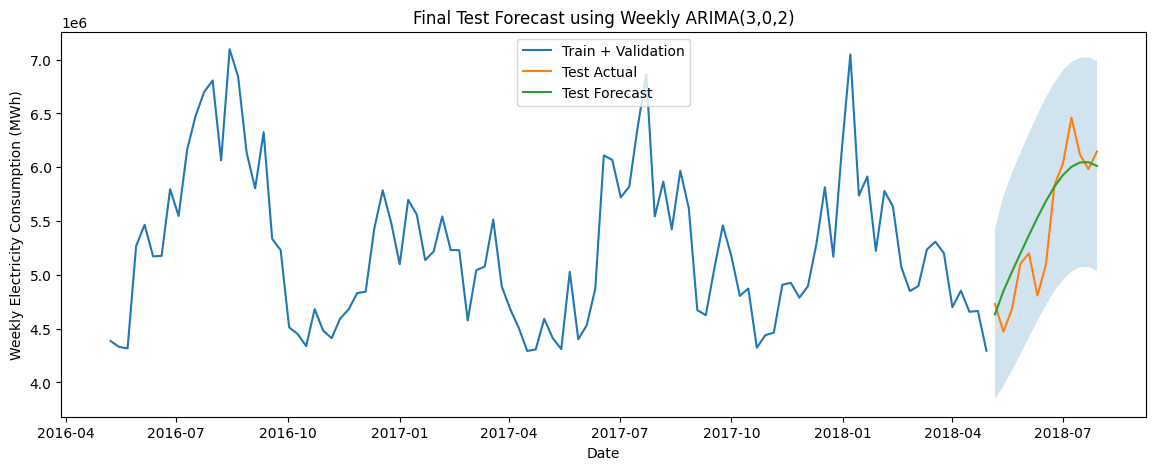

In [124]:
plt.figure(figsize=(14, 5))

plt.plot(train_val.iloc[-104:], label="Train + Validation")
plt.plot(test, label="Test Actual")
plt.plot(test_forecast, label="Test Forecast")

plt.fill_between(
    test_ci.index,
    test_ci.iloc[:, 0],
    test_ci.iloc[:, 1],
    alpha=0.2
)

plt.title("Final Test Forecast using Weekly ARIMA(3,0,2)")
plt.xlabel("Date")
plt.ylabel("Weekly Electricity Consumption (MWh)")
plt.legend()
plt.show()

In [125]:
# Compact forecast comparison table
forecast_comparison_compact = pd.DataFrame({
    "Actual_MWh": test,
    "MultiStep_Forecast_MWh": test_forecast,
    "Rolling_Forecast_MWh": rolling_forecast
})

forecast_comparison_compact["MultiStep_APE_%"] = (
    np.abs(
        forecast_comparison_compact["Actual_MWh"]
        - forecast_comparison_compact["MultiStep_Forecast_MWh"]
    )
    / forecast_comparison_compact["Actual_MWh"]
) * 100

forecast_comparison_compact["Rolling_APE_%"] = (
    np.abs(
        forecast_comparison_compact["Actual_MWh"]
        - forecast_comparison_compact["Rolling_Forecast_MWh"]
    )
    / forecast_comparison_compact["Actual_MWh"]
) * 100

forecast_comparison_compact["MultiStep_Accuracy_%"] = (
    100 - forecast_comparison_compact["MultiStep_APE_%"]
)

forecast_comparison_compact["Rolling_Accuracy_%"] = (
    100 - forecast_comparison_compact["Rolling_APE_%"]
)

forecast_comparison_compact = forecast_comparison_compact.round(2)

display(forecast_comparison_compact)

,Actual_MWh,MultiStep_Forecast_MWh,Rolling_Forecast_MWh,MultiStep_APE_%,Rolling_APE_%,MultiStep_Accuracy_%,Rolling_Accuracy_%
Datetime,,,,,,,
2018-05-06,4728863.0,4632112.39,4632112.39,2.05,2.05,97.95,97.95
2018-05-13,4471506.0,4848939.59,4895793.86,8.44,9.49,91.56,90.51
2018-05-20,4679496.0,5027961.62,4839580.46,7.45,3.42,92.55,96.58
2018-05-27,5104242.0,5198603.09,5004022.55,1.85,1.96,98.15,98.04
2018-06-03,5198861.0,5367494.39,5286858.69,3.24,1.69,96.76,98.31
2018-06-10,4807346.0,5531738.86,5412419.33,15.07,12.59,84.93,87.41
2018-06-17,5093246.0,5684744.40,5278239.71,11.61,3.63,88.39,96.37
2018-06-24,5831557.0,5818952.26,5449766.42,0.22,6.55,99.78,93.45
2018-07-01,6033189.0,5927243.61,5852378.40,1.76,3.00,98.24,97.00


In [126]:
forecast_method_comparison = pd.DataFrame([
    {
        "Forecast Method": "Multi-step ARIMA Forecast",
        "MAE": test_mae,
        "RMSE": test_rmse,
        "MAPE_%": test_mape,
        "Forecast_Accuracy_%": 100 - test_mape
    },
    {
        "Forecast Method": "Rolling One-step ARIMA Forecast",
        "MAE": rolling_mae,
        "RMSE": rolling_rmse,
        "MAPE_%": rolling_mape,
        "Forecast_Accuracy_%": rolling_accuracy
    }
])

forecast_method_comparison = forecast_method_comparison.round(2)

display(forecast_method_comparison.sort_values("MAPE_%"))

,Forecast Method,MAE,RMSE,MAPE_%,Forecast_Accuracy_%
1,Rolling One-step ARIMA Forecast,235833.86,287700.39,4.45,95.55
0,Multi-step ARIMA Forecast,250006.38,332071.75,4.86,95.14


### Multi-step and Rolling One-step Forecast Comparison

This table compares the final multi-step ARIMA forecast with the rolling one-step ARIMA forecast on the test set. The multi-step forecast predicts the whole test period at once without updating the model with actual test observations. In contrast, the rolling one-step forecast predicts one week ahead and then updates the historical data with the newly observed actual value before forecasting the next week.

The rolling one-step forecast performs slightly better than the multi-step forecast. It achieves a lower MAE, RMSE, and MAPE, with a MAPE of 4.45% compared with 4.86% for the multi-step forecast. This result is expected because the rolling approach uses more recent information at each forecasting step.

However, the rolling one-step forecast should be interpreted as a supplementary short-term forecasting check, not as the main final forecast. The multi-step forecast remains the main out-of-sample evaluation because it forecasts the full test horizon without using actual test values during the forecasting process.

### SARIMA Extension Check

The ACF plot of the weekly training series suggests possible annual seasonality around lag 52. Since the data are weekly, lag 52 approximately represents the same week in the previous year. Therefore, SARIMA models are tested as an extension of the non-seasonal ARIMA model.

In this step, several SARIMA specifications are estimated using the training set and evaluated on the validation set. The seasonal period is set to 52 in order to capture possible annual weekly seasonality. The non-seasonal ARIMA orders are based on the two strongest candidate models from the previous ARIMA selection step, ARIMA(3,0,2) and ARIMA(4,0,3). The tested seasonal components include seasonal AR, seasonal MA, and combined seasonal ARMA terms.

The purpose of this step is not to replace the selected ARIMA model automatically, but to check whether adding seasonal components improves validation forecasting performance. The final decision is based on validation MAE, RMSE, MAPE, convergence status, and residual autocorrelation diagnostics. The test set is not used in this SARIMA selection step.


In [127]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

sarima_candidates = [
    ((3, 0, 2), (1, 0, 0, 52)),
    ((3, 0, 2), (0, 0, 1, 52)),
    ((3, 0, 2), (1, 0, 1, 52)),
    ((4, 0, 3), (1, 0, 0, 52)),
    ((4, 0, 3), (0, 0, 1, 52)),
    ((4, 0, 3), (1, 0, 1, 52)),
]

sarima_results = []

for order, seasonal_order in sarima_candidates:
    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False, maxiter=300)

        val_result = fitted.get_forecast(steps=len(val))
        val_forecast = val_result.predicted_mean
        val_forecast.index = val.index

        mae = mean_absolute_error(val, val_forecast)
        rmse = np.sqrt(mean_squared_error(val, val_forecast))
        mape = np.mean(np.abs((val - val_forecast) / val)) * 100

        residuals = fitted.resid.dropna()

        lb = acorr_ljungbox(
            residuals,
            lags=[4, 13, 26, 52],
            return_df=True
        )

        sarima_results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fitted.aic,
            "BIC": fitted.bic,
            "Validation_MAE": mae,
            "Validation_RMSE": rmse,
            "Validation_MAPE": mape,
            "Converged": fitted.mle_retvals.get("converged", None),
            "LB_pvalue_4": lb.loc[4, "lb_pvalue"],
            "LB_pvalue_13": lb.loc[13, "lb_pvalue"],
            "LB_pvalue_26": lb.loc[26, "lb_pvalue"],
            "LB_pvalue_52": lb.loc[52, "lb_pvalue"]
        })

    except Exception as e:
        print(f"SARIMA{order}{seasonal_order} failed: {e}")

sarima_results_df = pd.DataFrame(sarima_results).sort_values("Validation_RMSE")
display(sarima_results_df)

,order,seasonal_order,AIC,BIC,Validation_MAE,Validation_RMSE,Validation_MAPE,Converged,LB_pvalue_4,LB_pvalue_13,LB_pvalue_26,LB_pvalue_52
2,"(3, 0, 2)","(1, 0, 1, 52)",21217.378545,21258.886914,415150.593002,516690.966562,8.065031,True,1.796984e-25,2.966678e-43,1.159498e-77,5.875453e-100
0,"(3, 0, 2)","(1, 0, 0, 52)",21232.562344,21269.458673,422167.297137,525162.312256,8.116268,True,2.786482e-06,3.269805e-07,4.999603e-15,3.985457e-29
1,"(3, 0, 2)","(0, 0, 1, 52)",21249.908367,21286.804696,466428.007070,564056.771923,8.976316,True,2.486273e-01,6.469746e-08,3.270348e-15,5.232887e-35
4,"(4, 0, 3)","(0, 0, 1, 52)",21369.941380,21416.048340,496197.276919,599218.193344,9.779627,True,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,"(4, 0, 3)","(1, 0, 1, 52)",21369.105737,21419.823393,518828.294941,622355.158417,10.244579,True,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,"(4, 0, 3)","(1, 0, 0, 52)",21327.536965,21373.643925,519447.112392,631918.605816,10.278511,True,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [128]:
# Compare selected ARIMA with best SARIMA

# Get selected ARIMA(3,0,2) validation result
selected_arima_val = model_results[
    model_results["order"] == (3, 0, 2)
].iloc[0]

# Get best SARIMA result based on validation RMSE
best_sarima_val = sarima_results_df.iloc[0]

sarima_arima_comparison = pd.DataFrame([
    {
        "Model": "Selected ARIMA",
        "Order": str(selected_arima_val["order"]),
        "Seasonal_Order": "None",
        "Validation_MAE": selected_arima_val["Validation_MAE"],
        "Validation_RMSE": selected_arima_val["Validation_RMSE"],
        "Validation_MAPE_%": selected_arima_val["Validation_MAPE"]
    },
    {
        "Model": "Best SARIMA",
        "Order": str(best_sarima_val["order"]),
        "Seasonal_Order": str(best_sarima_val["seasonal_order"]),
        "Validation_MAE": best_sarima_val["Validation_MAE"],
        "Validation_RMSE": best_sarima_val["Validation_RMSE"],
        "Validation_MAPE_%": best_sarima_val["Validation_MAPE"]
    }
])

sarima_arima_comparison["Validation_Accuracy_%"] = (
    100 - sarima_arima_comparison["Validation_MAPE_%"]
)

sarima_arima_comparison = sarima_arima_comparison.round(2)

display(sarima_arima_comparison)

,Model,Order,Seasonal_Order,Validation_MAE,Validation_RMSE,Validation_MAPE_%,Validation_Accuracy_%
0,Selected ARIMA,"(3, 0, 2)",None,367409.68,455106.57,7.23,92.77
1,Best SARIMA,"(3, 0, 2)","(1, 0, 1, 52)",415150.59,516690.97,8.07,91.93


### SARIMA vs Selected ARIMA Comparison

The SARIMA models are tested because the ACF plot suggests possible annual seasonality around lag 52. Since the data are weekly, a seasonal period of 52 represents approximately one year.

The best SARIMA specification is SARIMA(3,0,2)(1,0,1,52), but its validation performance is worse than the selected non-seasonal ARIMA(3,0,2) model. The best SARIMA model has a validation MAPE of about 8.07%, while ARIMA(3,0,2) has a lower validation MAPE of about 7.23%.

Therefore, adding seasonal AR or MA terms does not improve validation forecasting performance in this project. SARIMA is considered as an extension check, but it is not selected as the final forecasting model. The final model remains ARIMA(3,0,2).

### Final Modeling Conclusion

This notebook evaluates baseline models, ARIMA models, rolling one-step forecasts, residual diagnostics, and SARIMA extensions for weekly electricity consumption forecasting.

The Naive and Seasonal Naive models are used as benchmark forecasts. The Seasonal Naive baseline performs better than the simple Naive baseline, indicating that annual weekly patterns are useful for forecasting electricity consumption. However, the selected ARIMA(3,0,2) model improves validation and test forecasting performance compared with both baseline models.

Although ARIMA(4,0,3) gives the lowest validation error among the non-seasonal ARIMA candidates, ARIMA(3,0,2) is selected as the final model because it provides a better balance between forecasting accuracy and model simplicity. The final multi-step test forecast achieves a MAPE of 4.86%, while the rolling one-step forecast achieves a slightly lower MAPE of 4.45%.

Residual diagnostics show that the model captures most short-term autocorrelation, but some annual seasonal autocorrelation remains around lag 52. Therefore, SARIMA models with seasonal period 52 are tested as an extension. However, the tested SARIMA specifications do not improve validation forecasting performance compared with ARIMA(3,0,2). As a result, ARIMA(3,0,2) remains the final selected model.

Overall, the selected ARIMA(3,0,2) model provides accurate and interpretable weekly electricity consumption forecasts. Future improvements could include external variables such as temperature, weather conditions, holidays, and calendar effects through ARIMAX or SARIMAX models.
